# Visualization of saved distance matrices


Visualize arrays saved in `\res` folder here.



In [12]:
import os
os.getcwd()

os.chdir('/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli/')


In [13]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

from grid.grid_functions import *


incidence = True # If true, use incidence data instead of proportions.

In [14]:
# Load the files:
res_root = "grid/res/14_years/"
print(res_root + "dists_obs_14y_incidence.npy")
dists = np.load(res_root + "dists_obs_14y_incidence.npy")
pairs = np.load(res_root + "pairs_obs_14y_incidence.npy")


true_par1 = 0.0853#0.0758#0.145 # For real data, use mean point estimate
true_par2 = 0.058#0.013 #0.036

grid/res/14_years/dists_obs_14y_incidence.npy


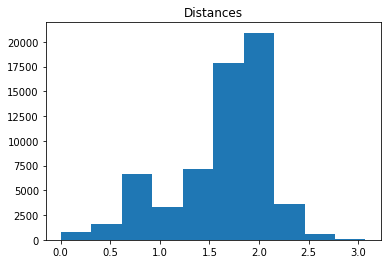

In [15]:
plt.hist(dists)
plt.title("Distances")
plt.show()

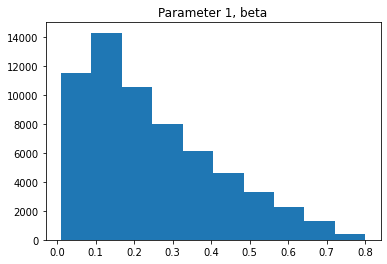

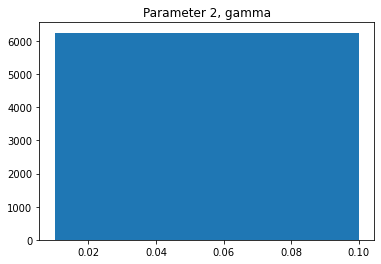

Overall mean of par1 (beta or net transmission) 0.24750027500000005
Overall mean of par2 (gamma or R) 0.05500000000000001


In [16]:
plt.hist(pairs[:,0])
plt.title("Parameter 1, beta") # or net transmission
plt.show()

plt.hist(pairs[:,1])
plt.title("Parameter 2, gamma") # or R
plt.show()

print("Overall mean of par1 (beta or net transmission)", np.mean(pairs[:,0]))
print("Overall mean of par2 (gamma or R)", np.mean(pairs[:,1]))

In [17]:
# Print point estimates:
eps = 0.4
print(f"Beta mean: {np.mean(pairs[np.where(dists< eps)[0],0])}")
print(f"Gamma mean: {np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"R = beta mean/gamma mean: {np.mean(pairs[np.where(dists < eps)[0],0])/np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"True parameters (for synthetic data): beta = {true_par1}, gamma = {true_par2}")

Beta mean: 0.08525374936690398
Gamma mean: 0.05954265337210913
R = beta mean/gamma mean: 1.431809711839923
True parameters (for synthetic data): beta = 0.0853, gamma = 0.058


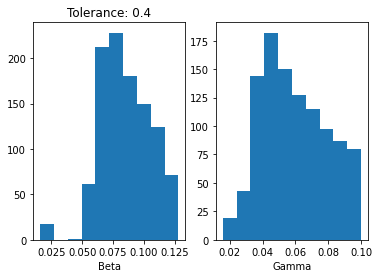

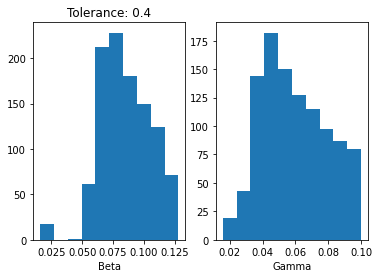

In [18]:
# Visualize:
plot_histograms(dists, pairs[:,0], pairs[:,1], eps, save = True, filename = res_root + "tolerance_hist_test.pdf")
plot_histograms(dists, pairs[:,0], pairs[:,1], eps, save = True, filename = res_root + "tolerance_hist_test.pdf")

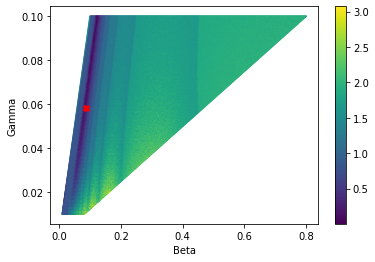

In [19]:
scatter_distance_points(pairs[:,0], pairs[:,1], dists, true_beta = true_par1, true_gamma = true_par2,\
                        save = True, filename = res_root + "grid_scatter_test.pdf")

Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
Year
2004    3.895481e-06
2005    3.949891e-10
2006    1.263574e-05
2007    4.214390e-06
2008    1.053623e-05
2009    5.791327e-06
2010    1.535184e-05
2011    8.640565e-06
2012    2.363202e-05
2013    3.185117e-05
2014    3.004447e-05
2015    1.012509e-05
2016    2.025119e-05
2017    2.130096e-05
Name: A, dtype: float64


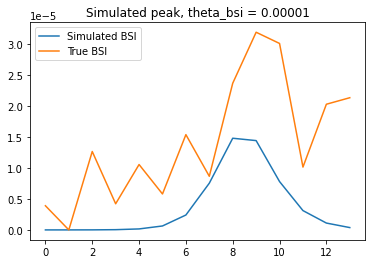

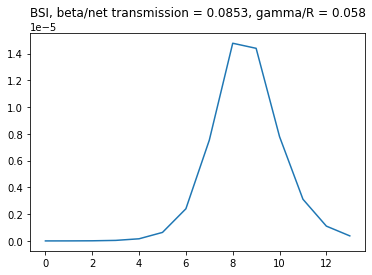

In [20]:
from cluster.scripts.load_data import *
n_weeks = 14*52
pop_size = 1000000
obs_data = "NORM"
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":1, "theta_bsi":0.00001}
bsi_real_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)

if incidence: 
    bsi_obs_data = get_incidence_data("data/NORM_incidence.csv", clade = clade, is_prop = True, n_incidence_pop = pop_size)
else:
    if obs_data == "NORM":
        bsi_obs_data = get_obs_BSI(df = norm_data, clade = clade, is_prop = True)
    else:
        bsi_obs_data = get_obs_BSI(df = bsac_data, clade = clade, is_prop = True)

print(bsi_obs_data)

plt.plot(bsi_real_sim[0], label = "Simulated BSI") # jos kerron sadalla, osuu tuohon yhteen piikkiin sentään.
plt.plot(np.array(bsi_obs_data), label = "True BSI")
plt.legend()
plt.title("Simulated peak, theta_bsi = 0.00001")
plt.savefig(res_root + "incidence_results_scaled" + ".pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.plot(bsi_real_sim[0])
plt.title(f"BSI, beta/net transmission = {true_par1}, gamma/R = {true_par2}")
plt.show()

### Aggregate example

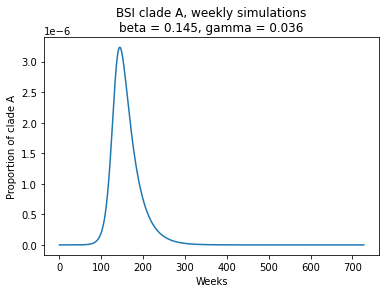

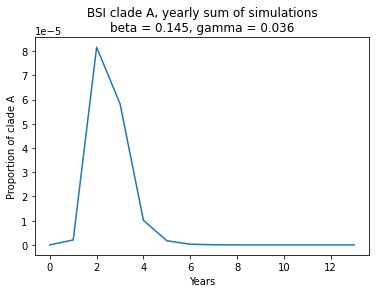

In [21]:
true_par1 = 0.145
true_par2 = 0.036



bsi_sim_agg = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)
bsi_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = False, time_period = 52, batch_size = 1, random_state = None)



plt.plot(bsi_sim[0])
plt.title(f"BSI clade A, weekly simulations\nbeta = {true_par1}, gamma = {true_par2}")
plt.ylabel("Proportion of clade A")
plt.xlabel("Weeks")
plt.show()

plt.plot(bsi_sim_agg[0])
plt.title(f"BSI clade A, yearly sum of simulations\nbeta = {true_par1}, gamma = {true_par2}")
plt.ylabel("Proportion of clade A")
plt.xlabel("Years")
plt.show()

# Simulated aggregated data, visualizing colonisation

In [22]:
# Load the files:
#res_root = "/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli/grid/res/16_years/" # or change working directory
print(res_root + "dists_synt_agg_16y.npy")
dists = np.load(res_root + "dists_synt_agg_16y.npy")
pairs = np.load(res_root + "pairs_synt_agg_16y.npy")


true_par1 = 0.145
true_par2 = 0.036 

grid/res/14_years/dists_synt_agg_16y.npy


FileNotFoundError: [Errno 2] No such file or directory: 'grid/res/14_years/dists_synt_agg_16y.npy'

In [ ]:
# Simulator settings
from cluster.scripts.load_data import *

n_weeks = 16*52
pop_size = 5000000
obs_data = "NORM"
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":1, "theta_bsi":0.001}
bsi_real_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)

if obs_data == "NORM":
    bsi_obs_data = get_obs_BSI(df = norm_data, clade = clade, is_prop = True)
else:
    bsi_obs_data = get_obs_BSI(df = bsac_data, clade = clade, is_prop = True)

print(bsi_obs_data)

In [ ]:
pairs.shape

n = 3
int(pairs.shape[0]/(n*n))


In [ ]:
pairs[100,1]

In [ ]:
n_weeks

In [ ]:
min(pairs[:,0])

In [ ]:
max(pairs[:,0])

In [ ]:
(max(pairs[:,0]) - min(pairs[:,0]))/3

In [ ]:
# Alternative: evenly spaced parameter pairs
n = 3

inc = int(pairs.shape[0]/(n*n))

min_par1 = np.min(pairs[:,0])
min_par2 = np.min(pairs[:,1])

max_par1 = np.max(pairs[:,0])
max_par2 = np.max(pairs[:,1])

print(min_par2, min_par2)
print(max_par1, max_par2)

stepsize = pairs[3,0] - pairs[2,0]
print(stepsize)

# First, find 3 gamma values, evenly spaced:

gammas = [min(pairs[:,1]), min(pairs[:,1]) + (max(pairs[:,1]) - min(pairs[:,1]))/3, max(pairs[:,1])]
betas  = [min(pairs[:,0]), min(pairs[:,0]) + (max(pairs[:,0]) - min(pairs[:,0]))/3, max(pairs[:,0])]

print(gammas)
print(betas)

x = np.arange(0, 16)
y = []
par1s = []
par2s = []

for b in betas:
    for g in gammas:
        
        y.append(SIR_and_BSI_simulator(np.array([b]), np.array([g]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)[0])
        
        
        par1s.append(b)
        par2s.append(g)


        
print(y[1].shape)
# The following lines are a courtesy of ChatGPT :D
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

x_tick_labels = [i + 1 for i in range(2001, 2017)]
print(x_tick_labels)
print(len(x_tick_labels))

y_min = 0
y_max = 0.03

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot the line plots in each subplot
for i, ax in enumerate(axes):
    ax.plot(x, y[i])
    ax.set_title(f'Beta = {np.round(par1s[i],3)}, gamma = {np.round(par2s[i],4)}')
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels, rotation = 90)
    
    point = ax.plot(BSI_max_t(y[i]), BSI_max(y[i]), "ro",label = "(BSI_max_t, BSI_max)")[0]
    ax.legend(handles = [point], loc='upper right')

# Adjust the spacing between subplots
plt.tight_layout()

# Display the grid of line plots
plt.show()

# Also show summaries
BSI_max(y[i])


# TODO: korjaa skaalaus

In [ ]:
sc = plt.scatter(pairs[:,0], pairs[:,1], c = dists, s = 1)

for i in range(0, 9):
    plt.scatter(par1s[i], par2s[i], c= "red", marker = "X")
plt.xlabel("Beta")
plt.ylabel("Gamma")
plt.colorbar(sc)
sc.set_cmap('viridis') # 'plasma'
#sc.set_clim(cutoff_lower, cutoff_upper)

In [ ]:
# Form a 3x3 grid of colonisation figures

import matplotlib.pyplot as plt
import numpy as np

# Generate some random data for the line plots
#x = np.linspace(0, n_weeks, )
x = np.arange(0, 16)



# Find nine parameter pair examples & visualize them in a grid

y = []

n = 3

inc = int(pairs.shape[0]/(n*n))

par1s = []
par2s = []

for i in range(0,9):
    
    if i == 0:
        j = i
    else:
        j += inc
    
    if j > pairs.shape[0]:
        j = pairs.shape[0] - 1

    print(j)
        
    y.append(SIR_and_BSI_simulator(np.array([pairs[j,0]]), np.array([pairs[j,1]]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)[0])
    
    par1s.append(pairs[j,0])
    par2s.append(pairs[j,1])
    
    
print(y[1].shape)
# The following lines are (mostly) a courtesy of ChatGPT :D
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

x_tick_labels = [i + 1 for i in range(2001, 2017)]
print(x_tick_labels)
print(len(x_tick_labels))

y_min = 0
y_max = 0.025

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot the line plots in each subplot
for i, ax in enumerate(axes):
    ax.plot(x, y[i])
    ax.set_title(f'Beta = {np.round(par1s[i],3)}, gamma = {np.round(par2s[i],4)}')
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels, rotation = 90)
    
    point = ax.plot(BSI_max_t(y[i]), BSI_max(y[i]), "ro",label = "(BSI_max_t, BSI_max)")[0]
    ax.legend(handles = [point], loc='upper right')

# Adjust the spacing between subplots
plt.tight_layout()

# Display the grid of line plots
plt.show()

# Also show summaries
BSI_max(y[i])

In [ ]:
sc = plt.scatter(pairs[:,0], pairs[:,1], c = dists, s = 1)

for i in range(0, 9):
    plt.scatter(par1s[i], par2s[i], c= "red", marker = "X")
plt.xlabel("Beta")
plt.ylabel("Gamma")
plt.colorbar(sc)
sc.set_cmap('viridis') # 'plasma'
#sc.set_clim(cutoff_lower, cutoff_upper)

# Use incidence instead of proportions

TODO
- What, if anything, would change in the observational model?
    - Need to change the proportions to incidence in the col_to_bsi function. Colonisation also in terms of incidence per 1 000 000 population.
    - Do this on pen and paper first.
    - I think the only change necessary is to use counts instead of proportions with a population size of 1000000. Or proportions, but just change the population size.
- Load the data
- Fit in Triton.

In addtion
- Cutoff from 2005
    - Incidence data starts from 2004.

In [ ]:
# Read incidence


csv_file = 'data/NORM_incidence.csv'
df = pd.read_csv(csv_file, delimiter=',')

df["A"]
df["Year"]

def get_incidence_data(csv_file, clade = "A", is_prop = True, n_incidence_pop = 1000000):
    # Get the BSI clade X incidence per 1000000 people.
    # If is_prop = True, divides the incidence by n_incidence_pop
    
    import pandas as pd

    csv_file = 'data/NORM_incidence.csv'
    df = pd.read_csv(csv_file, delimiter=',')
    
    rnames = df["Year"]
    
    df = df[clade]
    
    if is_prop:
        df = df/n_incidence_pop
     
    df.index = rnames
    
    return df

obs_data_A = get_incidence_data(csv_file, clade = "A", is_prop = True)
obs_data_C2 = get_incidence_data(csv_file, clade = "C2", is_prop = True)

# Plot the incidence data:

plt.plot(obs_data_A, label = "Clade A")
plt.plot(obs_data_C2, label = "Clade C2")
plt.title("BSI clade cases/1000000")
plt.legend()
plt.show()

In [ ]:
df["Year"]

# Find the number of BSI cases at the beginning

The data does not start at zero, at least not with clade A. Find the initial number of BSI cases to get $I_0$ and $S_0$ for the SIR model. $I_0$ is the number/proportion/incidence of colonized at the start of the study period.



In [ ]:
obs_data_A = get_incidence_data(csv_file, clade = "A", is_prop = True)